In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [2]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f1 only
function_folder = os.path.join(base_dir, "function_2")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f2 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 2: shape = {df_f2.shape}, columns = {df_f2.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 2: shape = (10, 3), columns = ['X1', 'X2', 'y1']


In [3]:
week1_results = {"f2": ([0.554975, 0.999446], -0.07640833812988071)}

In [4]:
week2_results = {"f2": ([0.999500, 0.001800], -0.07975546223482953)}

In [5]:
week3_results = {"f2": ([0.727681, 0.187140], 0.5037032225936308)}

In [6]:
week4_results = {"f2": ([0.715483, 0.563901], 0.5661662506769448)}

In [7]:
week5_results = {"f2": ([0.678746, 0.850809], 0.6824523528240423)}

In [8]:
week6_results = {"f2": ([0.653993, 0.981188], 0.3798198130144502)}

In [9]:
week7_results = {"f2": ([0.000128, 0.346419], 0.005940965665866974)}

In [10]:
week8_results = {"f2": ([0.920304, 0.040061], -0.03174629008935288)}

In [11]:
week9_results = {"f2": ([0.695009, 0.789642], 0.5760952219798307)}

In [12]:
week10_results = {"f2": ([0.685000, 0.065000], 0.3296260629146929)}

In [13]:
week11_results = {"f2": ([0.679000, 0.891724], 0.5741619847231454)}

In [14]:
week12_results = {"f2": ([0.703000, 0.869000], 0.6373246839785176)}

In [15]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
    "week11": week11_results,
    "week12": week12_results,
}

output_col = output_cols[0]   # this gives "y1"

# add weekly results to df_f2

for week, results in weekly_results.items():
    
    if "f2" not in results:
        continue
    
    inputs, output = results["f2"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f2
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "y1"]
    )
    
    # append to df_f2
    df_f2 = pd.concat([df_f2, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f2 = df_f2.drop_duplicates(ignore_index=True)

print("updated f2 shape:", df_f2.shape)


updated f2 shape: (22, 3)


In [16]:
print(df_f2)

          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.554975  0.999446 -0.076408
11  0.999500  0.001800 -0.079755
12  0.727681  0.187140  0.503703
13  0.715483  0.563901  0.566166
14  0.678746  0.850809  0.682452
15  0.653993  0.981188  0.379820
16  0.000128  0.346419  0.005941
17  0.920304  0.040061 -0.031746
18  0.695009  0.789642  0.576095
19  0.685000  0.065000  0.329626
20  0.679000  0.891724  0.574162
21  0.703000  0.869000  0.637325


In [17]:
display(df_f2.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,22.0,0.608997,0.242828,0.000128,0.479729,0.678873,0.712362,0.999500
X2,22.0,0.521156,0.356351,0.001800,0.193822,0.624460,0.835517,0.999446
y1,22.0,0.289733,0.273173,-0.079755,0.010232,0.311809,0.559374,0.682452


## Pearson Correlation

f2 Pearson Correlation Matrix (raw y1)


,X1,X2,y1
X1,1.000000,0.114386,0.385934
X2,0.114386,1.000000,0.442283
y1,0.385934,0.442283,1.000000


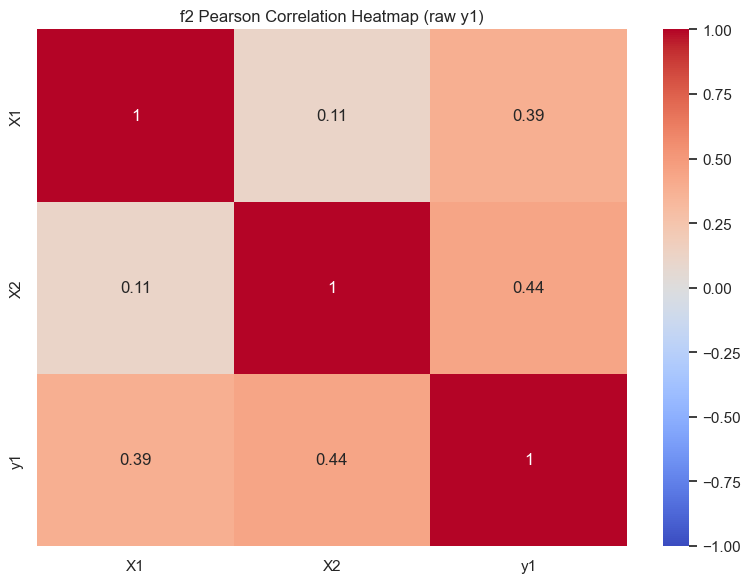

In [18]:
df_raw = df_f2.copy()

print("f2 Pearson Correlation Matrix (raw y1)")

corr_raw = df_raw.corr()
display(corr_raw)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f2 Pearson Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()

## Spearman Correlation

f2 Spearman Correlation Matrix (raw y1)


,X1,X2,y1
X1,1.000000,-0.036702,0.305477
X2,-0.036702,1.000000,0.453416
y1,0.305477,0.453416,1.000000


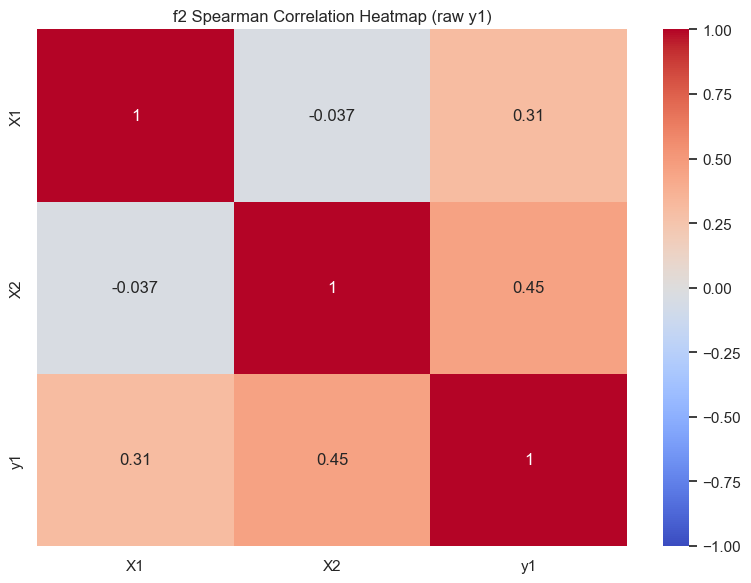

In [19]:
# spearman correlation with raw y1
df_raw = df_f2.copy()

print("f2 Spearman Correlation Matrix (raw y1)")

corr_raw_spearman = df_raw.corr(method="spearman")
display(corr_raw_spearman)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f2 Spearman Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Kendall Correlation

f2 Kendall Correlation Matrix (raw y1)


,X1,X2,y1
X1,1.000000,-0.047619,0.229437
X2,-0.047619,1.000000,0.341991
y1,0.229437,0.341991,1.000000


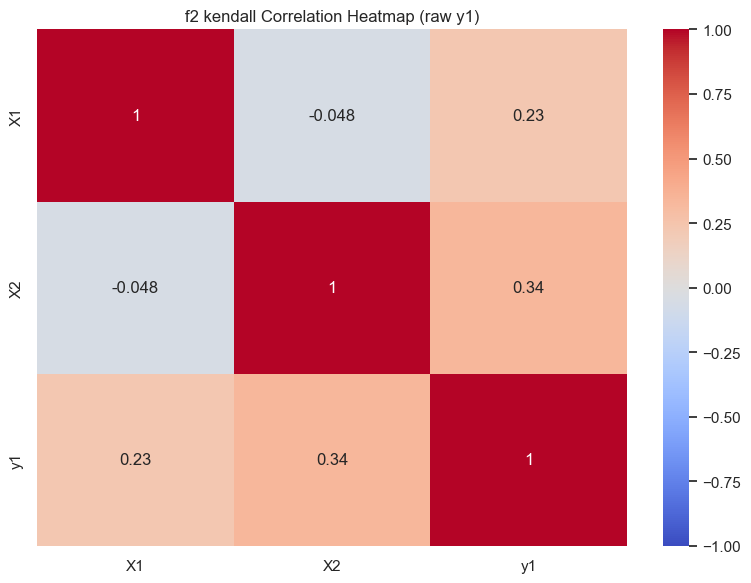

In [20]:
# Kendall correlation with raw y1
df_raw = df_f2.copy()

print("f2 Kendall Correlation Matrix (raw y1)")

corr_raw_kendall = df_raw.corr(method="kendall")
display(corr_raw_kendall)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_kendall,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f2 kendall Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Partial Correlation

In [21]:
!pip install pingouin
import pingouin as pg

In [22]:
print("f2 (Raw y1) — Partial Correlation")

# copy raw f2
df_f2_raw = df_f2.copy()

# define inputs and output
input_cols_f2 = [c for c in df_f2_raw.columns if c.startswith("X")]
output_col_f2 = "y1"

# compute partial correlations for each X feature
for x in input_cols_f2:
    covars = [c for c in input_cols_f2 if c != x]  # all other X's as covariates
    
    pcorr_raw_f2 = pg.partial_corr(
        data=df_f2_raw,
        x=x,
        y=output_col_f2,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_raw_f2)



f2 (Raw y1) — Partial Correlation

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,22,0.376372,"[-0.07, 0.7]",0.092641



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,22,0.434425,"[0.0, 0.73]",0.049084


## Pairwise scatter coloured by y rank



Feature vs y1 (RAW) for f2


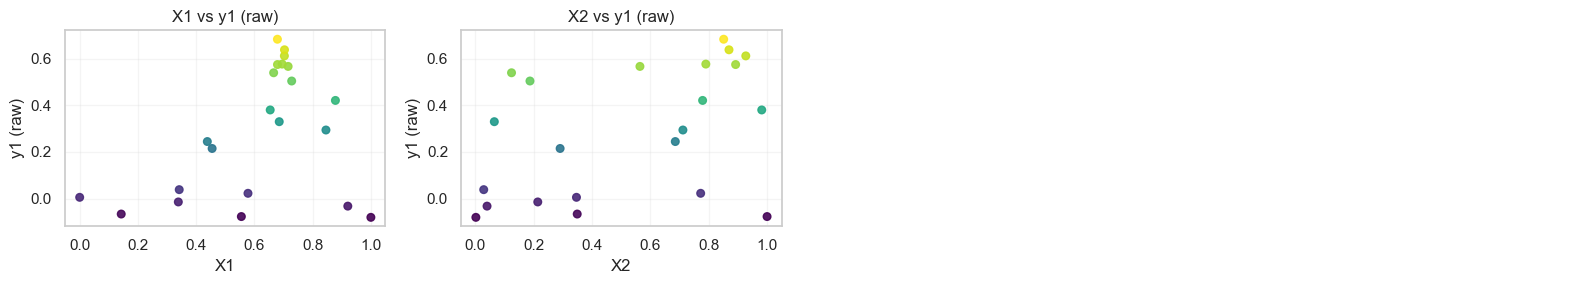

In [23]:
# === Feature vs RAW y1 for f2 ===
print("\nFeature vs y1 (RAW) for f2")

# copy raw f2
df_f2_raw = df_f2.copy()

# define inputs and output
input_cols_f2 = [c for c in df_f2_raw.columns if c.startswith("X")]
output_col_f2 = "y1"

# extract X and y
X_f2 = df_f2_raw[input_cols_f2].values
y_f2 = df_f2_raw[output_col_f2].values

# number of input features
n_features = X_f2.shape[1]
ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

# robust flattening
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.ravel().tolist()

# plot each feature
for j, col in enumerate(input_cols_f2):
    ax = axes[j]
    sc = ax.scatter(
        X_f2[:, j],
        y_f2,
        c=y_f2,
        cmap="viridis",
        s=30,
        alpha=0.9
    )
    ax.set_xlabel(col)
    ax.set_ylabel("y1 (raw)")
    ax.set_title(f"{col} vs y1 (raw)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## Empirical Variogram

Total pairs: 231 (expected 190 for N=20)

Empirical Variogram Diagnostics
Min distance:        0.0303
Max distance:        1.0922
Mean distance:       0.5391
Median distance:     0.6038

Min (y_i - y_j)^2:   0.000004
Max (y_i - y_j)^2:   0.580961
Mean (y_i - y_j)^2:  0.149247
Median (y_i - y_j)^2:0.086658

Binned Variogram Statistics
Bin 1: dist ∈ [0.030, 0.163] count= 26, mean=0.079661, median=0.013876, var=0.016102
Bin 2: dist ∈ [0.163, 0.296] count= 36, mean=0.151431, median=0.081476, var=0.025823
Bin 3: dist ∈ [0.296, 0.429] count= 32, mean=0.111943, median=0.103226, var=0.012133
Bin 4: dist ∈ [0.429, 0.561] count= 14, mean=0.098132, median=0.056459, var=0.013988
Bin 5: dist ∈ [0.561, 0.694] count= 35, mean=0.126805, median=0.067124, var=0.018431
Bin 6: dist ∈ [0.694, 0.827] count= 43, mean=0.173963, median=0.104772, var=0.029313
Bin 7: dist ∈ [0.827, 0.959] count= 34, mean=0.252377, median=0.287704, var=0.031774
Bin 8: dist ∈ [0.959, 1.092] count= 10, mean=0.149801, median=0.14285

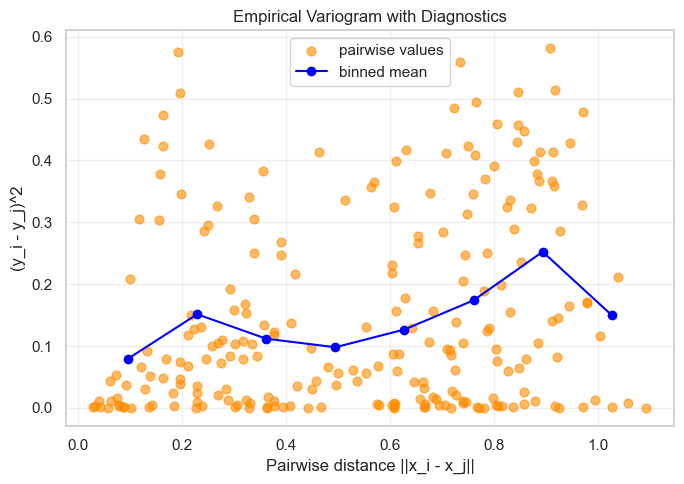

In [24]:
from scipy.spatial.distance import pdist, squareform

# X_f2 : shape (20, d)
# y_f2 : shape (20,)

# 1. Pairwise Euclidean distances
D = squareform(pdist(X_f2, metric="euclidean"))   # (20×20)

# 2. Pairwise squared y-differences
Ydiff = squareform(pdist(y_f2.reshape(-1,1), metric="euclidean"))**2

# 3. Extract unique pairs (upper triangle)
distances = D[np.triu_indices_from(D, k=1)]
sq_diffs  = Ydiff[np.triu_indices_from(Ydiff, k=1)]

print(f"Total pairs: {len(distances)} (expected 190 for N=20)\n")

# === Global numerical diagnostics ===
print("Empirical Variogram Diagnostics")
print(f"Min distance:        {distances.min():.4f}")
print(f"Max distance:        {distances.max():.4f}")
print(f"Mean distance:       {distances.mean():.4f}")
print(f"Median distance:     {np.median(distances):.4f}")
print()

print(f"Min (y_i - y_j)^2:   {sq_diffs.min():.6f}")
print(f"Max (y_i - y_j)^2:   {sq_diffs.max():.6f}")
print(f"Mean (y_i - y_j)^2:  {sq_diffs.mean():.6f}")
print(f"Median (y_i - y_j)^2:{np.median(sq_diffs):.6f}")
print()

# Correlation length heuristic:
# If small distances already have large squared differences → short correlation length
# If squared differences grow slowly with distance → long correlation length

# 4. Bin distances for a smooth variogram curve
n_bins = 8
bins = np.linspace(distances.min(), distances.max(), n_bins+1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

bin_means = []
bin_medians = []
bin_vars = []
bin_counts = []

for i in range(n_bins):
    mask = (distances >= bins[i]) & (distances < bins[i+1])
    vals = sq_diffs[mask]
    bin_counts.append(vals.size)
    if vals.size > 0:
        bin_means.append(vals.mean())
        bin_medians.append(np.median(vals))
        bin_vars.append(vals.var())
    else:
        bin_means.append(np.nan)
        bin_medians.append(np.nan)
        bin_vars.append(np.nan)

print("Binned Variogram Statistics")
for i in range(n_bins):
    print(f"Bin {i+1}: dist ∈ [{bins[i]:.3f}, {bins[i+1]:.3f}] "
          f"count={bin_counts[i]:3d}, mean={bin_means[i]:.6f}, "
          f"median={bin_medians[i]:.6f}, var={bin_vars[i]:.6f}")

# 5. Plot empirical variogram
plt.figure(figsize=(7,5))
plt.scatter(distances, sq_diffs, s=40, alpha=0.6, color="darkorange", label="pairwise values")

# binned curve
plt.plot(bin_centers, bin_means, "-o", color="blue", label="binned mean")

plt.xlabel("Pairwise distance ||x_i - x_j||")
plt.ylabel("(y_i - y_j)^2")
plt.title("Empirical Variogram with Diagnostics")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



## Convex hull coverage plot

Convex Hull Coverage Diagnostics
Number of points:           22
Convex hull vertices:       6
Convex hull area:           0.6417
Domain area (unit square):  1.0000
Coverage ratio:             0.6417

Distance of points to hull boundary:
  min distance:             0.0000
  max distance:             0.2662
  mean distance:            0.0765

Points far from hull boundary (extrapolation risk):
  index 4: dist=0.2662, X=[0.45464714 0.29045518], y=0.2150
  index 5: dist=0.1646, X=[0.57771284 0.77197318], y=0.0231
  index 6: dist=0.1146, X=[0.43816606 0.68501826], y=0.2446
  index 8: dist=0.1335, X=[0.33864816 0.21386725], y=-0.0139
  index 12: dist=0.1741, X=[0.727681 0.18714 ], y=0.5037
  index 13: dist=0.1936, X=[0.715483 0.563901], y=0.5662


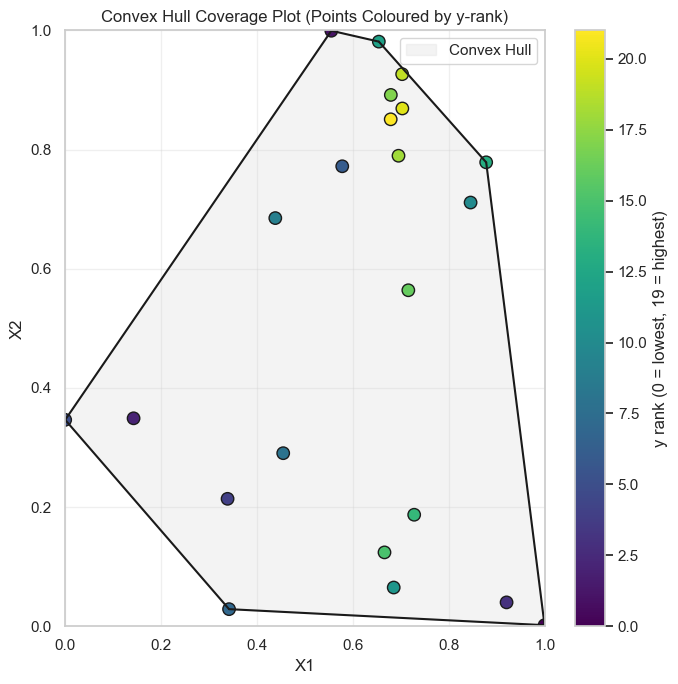

In [25]:
from scipy.spatial import ConvexHull, distance

# 1. Compute convex hull
hull = ConvexHull(X_f2)

# 2. Rank y-values for colour mapping
y_rank = np.argsort(np.argsort(y_f2))  # 0..19

# 3. Compute hull polygon for plotting
hull_vertices = X_f2[hull.vertices]

# 4. Compute distances of all points to hull boundary
def point_to_hull_distance(point, hull_points):
    # distance to each hull edge
    dists = []
    for i in range(len(hull_points)):
        p1 = hull_points[i]
        p2 = hull_points[(i+1) % len(hull_points)]
        # line segment distance
        v = p2 - p1
        w = point - p1
        t = np.dot(w, v) / np.dot(v, v)
        t = np.clip(t, 0, 1)
        proj = p1 + t * v
        dists.append(np.linalg.norm(point - proj))
    return min(dists)

dist_to_hull = np.array([point_to_hull_distance(X_f2[i], hull_vertices) for i in range(len(X_f2))])

# 5. Compute coverage diagnostics
hull_area = hull.volume  # area in 2D
domain_area = 1.0        # unit square
coverage_ratio = hull_area / domain_area

min_dist = dist_to_hull.min()
max_dist = dist_to_hull.max()
mean_dist = dist_to_hull.mean()

# === Print diagnostics ===
print("Convex Hull Coverage Diagnostics")
print(f"Number of points:           {len(X_f2)}")
print(f"Convex hull vertices:       {len(hull.vertices)}")
print(f"Convex hull area:           {hull_area:.4f}")
print(f"Domain area (unit square):  1.0000")
print(f"Coverage ratio:             {coverage_ratio:.4f}")
print()
print("Distance of points to hull boundary:")
print(f"  min distance:             {min_dist:.4f}")
print(f"  max distance:             {max_dist:.4f}")
print(f"  mean distance:            {mean_dist:.4f}")
print()
print("Points far from hull boundary (extrapolation risk):")
for i in np.where(dist_to_hull > np.percentile(dist_to_hull, 75))[0]:
    print(f"  index {i}: dist={dist_to_hull[i]:.4f}, X={X_f2[i]}, y={y_f2[i]:.4f}")

# 6. Plot convex hull coverage
plt.figure(figsize=(7,7))

# hull polygon
plt.fill(hull_vertices[:,0], hull_vertices[:,1], 
         alpha=0.25, color="lightgray", label="Convex Hull")

# all points coloured by y-rank
plt.scatter(X_f2[:,0], X_f2[:,1], 
            c=y_rank, cmap="viridis", s=80, edgecolor="k")

# hull boundary
for simplex in hull.simplices:
    plt.plot(X_f2[simplex,0], X_f2[simplex,1], "k-", linewidth=1.5)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Convex Hull Coverage Plot (Points Coloured by y-rank)")
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.colorbar(label="y rank (0 = lowest, 19 = highest)")
plt.legend()
plt.tight_layout()
plt.show()


## Topological Data Analysis

In [26]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import networkx as nx

In [27]:
def build_mapper_graph(X, filter_vals, n_intervals=5, overlap_frac=0.35,
                       cluster_eps=0.40, cluster_min_samples=2):
    """
    simple mapper implementation:
      - 1D filter function
      - interval cover with overlap
      - DBSCAN clustering inside each interval
      - nodes represent clusters
      - edges connect nodes sharing data points
    """

    X = np.asarray(X)
    filter_vals = np.asarray(filter_vals)

    # compute interval boundaries
    fmin, fmax = filter_vals.min(), filter_vals.max()
    interval_length = (fmax - fmin) / n_intervals
    overlap = interval_length * overlap_frac

    intervals = []
    for i in range(n_intervals):
        start = fmin + i * interval_length - overlap
        end = fmin + (i + 1) * interval_length + overlap
        intervals.append((start, end))

    G = nx.Graph()
    node_id = 0

    # store cluster membership for edge construction
    interval_clusters = []

    for (start, end) in intervals:
        # points inside interval
        mask = (filter_vals >= start) & (filter_vals <= end)
        idxs = np.where(mask)[0]

        if len(idxs) == 0:
            interval_clusters.append([])
            continue

        X_sub = X[idxs]

        # cluster inside interval
        labels = DBSCAN(eps=cluster_eps, min_samples=cluster_min_samples).fit_predict(X_sub)
        unique_labels = set(labels)

        clusters = []
        for lab in unique_labels:
            if lab == -1:
                continue  # ignore noise
            cluster_indices = idxs[labels == lab]

            # add node
            G.add_node(node_id, indices=cluster_indices, size=len(cluster_indices))
            clusters.append(node_id)
            node_id += 1

        interval_clusters.append(clusters)

    # build edges: clusters sharing points
    for i in range(len(interval_clusters) - 1):
        for a in interval_clusters[i]:
            for b in interval_clusters[i + 1]:
                # check overlap in data indices
                A = set(G.nodes[a]["indices"])
                B = set(G.nodes[b]["indices"])
                if len(A & B) > 0:
                    G.add_edge(a, b)

    return G

Mapper for f2 (raw y)
  mapper diagnostics: nodes=7, edges=5, connected_components=2
  node size: mean=4.86, min=2, max=8
  top nodes by max y (node, size, mean_y, max_y):
    node 6: size=8, mean_y=0.5863, max_y=0.6825
    node 5: size=8, mean_y=0.4861, max_y=0.5761
    node 4: size=6, mean_y=0.3139, max_y=0.4206
    node 3: size=4, mean_y=0.1304, max_y=0.2446
    node 0: size=4, mean_y=-0.0087, max_y=0.0387


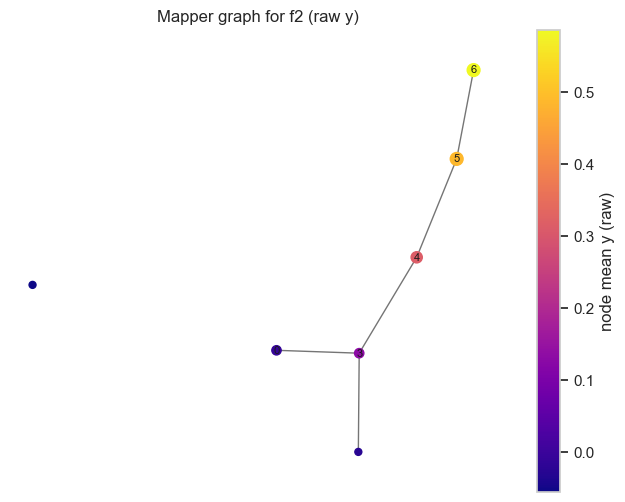

In [28]:
print("Mapper for f2 (raw y)")

# filter values = raw y_f2
filter_vals = y_f2.copy()

# build mapper graph
G_f2 = build_mapper_graph(
    X_f2,
    filter_vals,
    n_intervals=5,
    overlap_frac=0.35,
    cluster_eps=0.40,
    cluster_min_samples=2
)

# diagnostics
n_nodes = G_f2.number_of_nodes()
n_edges = G_f2.number_of_edges()
n_components = nx.number_connected_components(G_f2)

print(f"  mapper diagnostics: nodes={n_nodes}, edges={n_edges}, connected_components={n_components}")

if n_nodes > 0:
    node_sizes = np.array([G_f2.nodes[n]["size"] for n in G_f2.nodes])
    print(f"  node size: mean={node_sizes.mean():.2f}, min={node_sizes.min():.0f}, max={node_sizes.max():.0f}")

    # compute node-level y statistics
    node_max_y = []
    node_mean_y = []

    for nkey in G_f2.nodes:
        idxs = G_f2.nodes[nkey]["indices"]
        node_max_y.append(float(filter_vals[idxs].max()))
        node_mean_y.append(float(filter_vals[idxs].mean()))

    node_max_y = np.array(node_max_y)
    node_mean_y = np.array(node_mean_y)

    # top 5 nodes by max y
    top_idx = np.argsort(node_max_y)[::-1][:5]
    print("  top nodes by max y (node, size, mean_y, max_y):")
    for t in top_idx:
        nkey = list(G_f2.nodes)[t]   # FIXED: was G_f1
        print(
            f"    node {nkey}: size={G_f2.nodes[nkey]['size']}, "
            f"mean_y={node_mean_y[t]:.4f}, max_y={node_max_y[t]:.4f}"
        )

# plot mapper graph
if n_nodes > 0:
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G_f2, seed=0)

    node_colors = [np.mean(filter_vals[G_f2.nodes[n]["indices"]]) for n in G_f2.nodes]
    node_sizes_plot = [
        5 + 80 * (G_f2.nodes[n]["size"] / node_sizes.max())
        for n in G_f2.nodes
    ]

    nodes = nx.draw_networkx_nodes(
        G_f2, pos,
        node_color=node_colors,
        cmap="plasma",
        node_size=node_sizes_plot
    )
    nx.draw_networkx_edges(G_f2, pos, alpha=0.6)

    # label only larger nodes
    labels = {
        n: f"{n}"
        for n in G_f2.nodes
        if G_f2.nodes[n]["size"] >= max(2, int(node_sizes.mean()))
    }
    nx.draw_networkx_labels(G_f2, pos, labels=labels, font_size=8)

    plt.colorbar(nodes, label="node mean y (raw)")
    plt.title("Mapper graph for f2 (raw y)")
    plt.axis("off")
    plt.show()

# store results
results_f2_mapper = {
    "graph": G_f2,
    "filter_vals": filter_vals,
    "input_cols": input_cols_f2,
    "output_col": output_col_f2
}


## K-means Clustering

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

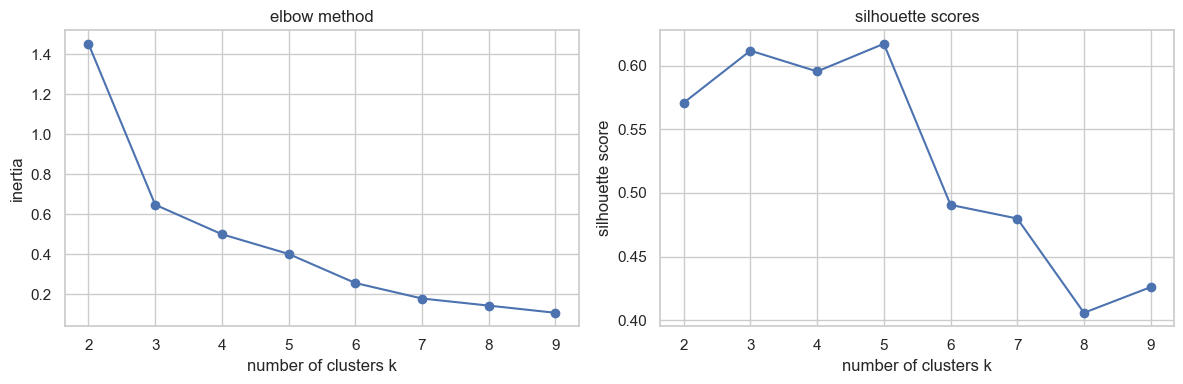

best number of clusters based on silhouette score: 5
cluster labels added to f2 dataframe


,X1,X2,y1,cluster
0,0.665800,0.123969,0.538996,2
1,0.877791,0.778628,0.420586,1
2,0.142699,0.349005,-0.065624,3
3,0.845275,0.711120,0.293993,1
4,0.454647,0.290455,0.214965,0


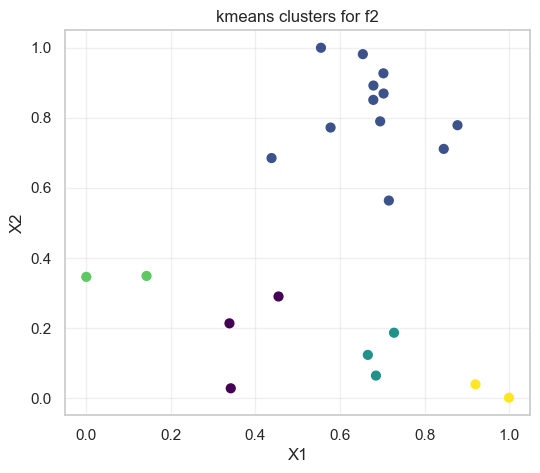

In [30]:
# prepare data
df_f2_kmeans = df_f2.copy()
input_cols_f2 = [c for c in df_f2_kmeans.columns if c.startswith("X")]
X_f2 = df_f2_kmeans[input_cols_f2].values

# test k from 2 to 9
k_values = range(2, 10)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_f2)

    inertias.append(km.inertia_)

    labels = km.labels_
    score = silhouette_score(X_f2, labels)
    sil_scores.append(score)

# plot elbow + silhouette
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker="o")
plt.xlabel("number of clusters k")
plt.ylabel("inertia")
plt.title("elbow method")

plt.subplot(1, 2, 2)
plt.plot(k_values, sil_scores, marker="o")
plt.xlabel("number of clusters k")
plt.ylabel("silhouette score")
plt.title("silhouette scores")

plt.tight_layout()
plt.show()

# choose best k
best_k = k_values[np.argmax(sil_scores)]
print("best number of clusters based on silhouette score:", best_k)

# fit final model
kmeans_final = KMeans(n_clusters=best_k, random_state=42)
kmeans_final.fit(X_f2)

cluster_labels = kmeans_final.labels_

# add labels to dataframe
df_f2_kmeans["cluster"] = cluster_labels

print("cluster labels added to f2 dataframe")
display(df_f2_kmeans.head())

# optional scatter plot (only if 2D)
if X_f2.shape[1] == 2:
    plt.figure(figsize=(6, 5))
    plt.scatter(
        X_f2[:, 0], X_f2[:, 1],
        c=cluster_labels,
        cmap="viridis",
        s=40
    )
    plt.xlabel(input_cols_f2[0])
    plt.ylabel(input_cols_f2[1])
    plt.title("kmeans clusters for f2")
    plt.grid(alpha=0.3)
    plt.show()

## Hierarchical Clustering

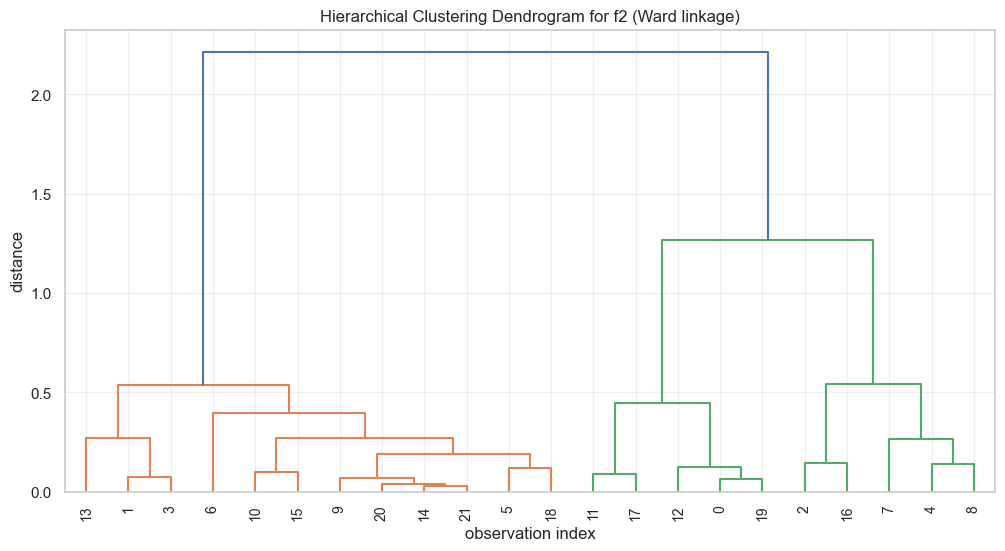

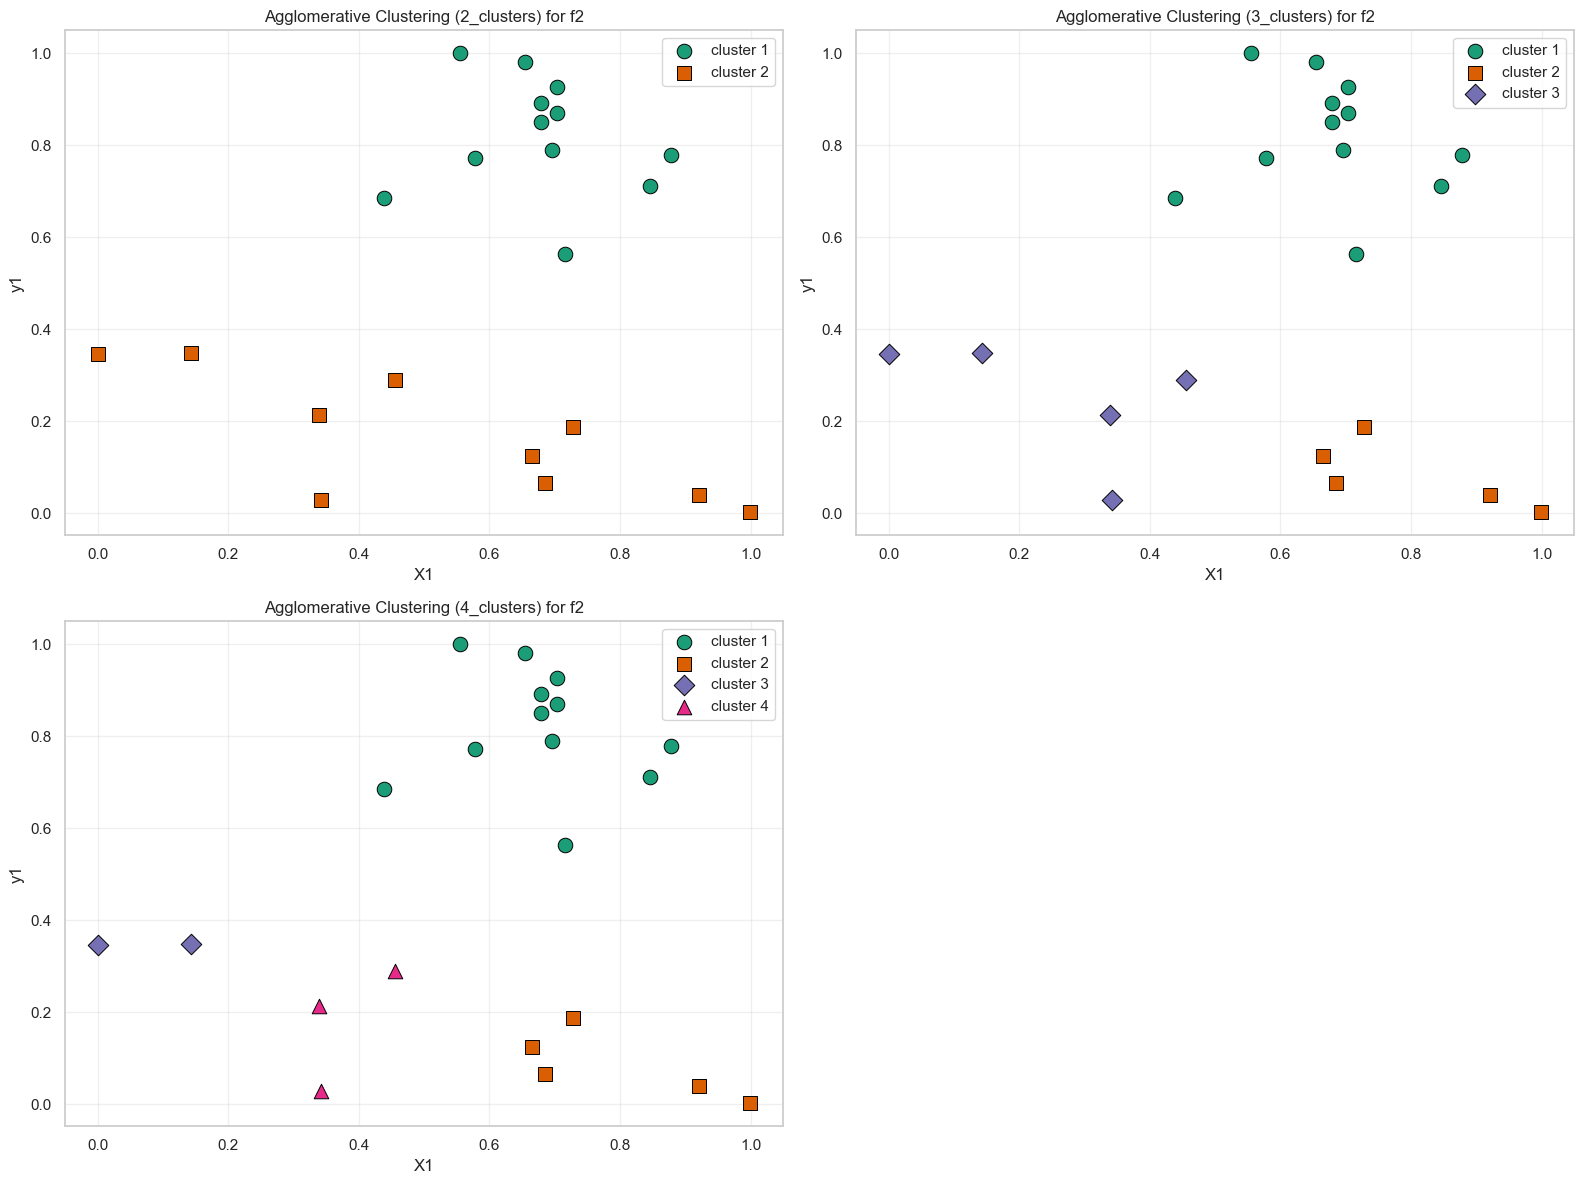


=== Centroid Diagnostics for 2_clusters ===
cluster 1: centroid = [0.67681566 0.81825112]
cluster 2: centroid = [0.52761565 0.16464144]

centroid distance matrix:
          1         2
1  0.000000  0.670422
2  0.670422  0.000000

=== Centroid Diagnostics for 3_clusters ===
cluster 1: centroid = [0.67681566 0.81825112]
cluster 2: centroid = [0.79965692 0.08359403]
cluster 3: centroid = [0.25557439 0.24568886]

centroid distance matrix:
          1         2         3
1  0.000000  0.744856  0.710825
2  0.744856  0.000000  0.567715
3  0.710825  0.567715  0.000000

=== Centroid Diagnostics for 4_clusters ===
cluster 1: centroid = [0.67681566 0.81825112]
cluster 2: centroid = [0.79965692 0.08359403]
cluster 3: centroid = [0.07141354 0.34771207]
cluster 4: centroid = [0.3783483  0.17767338]

centroid distance matrix:
          1         2         3         4
1  0.000000  0.744856  0.766759  0.706698
2  0.744856  0.000000  0.774659  0.431685
3  0.766759  0.774659  0.000000  0.350888
4  0.706

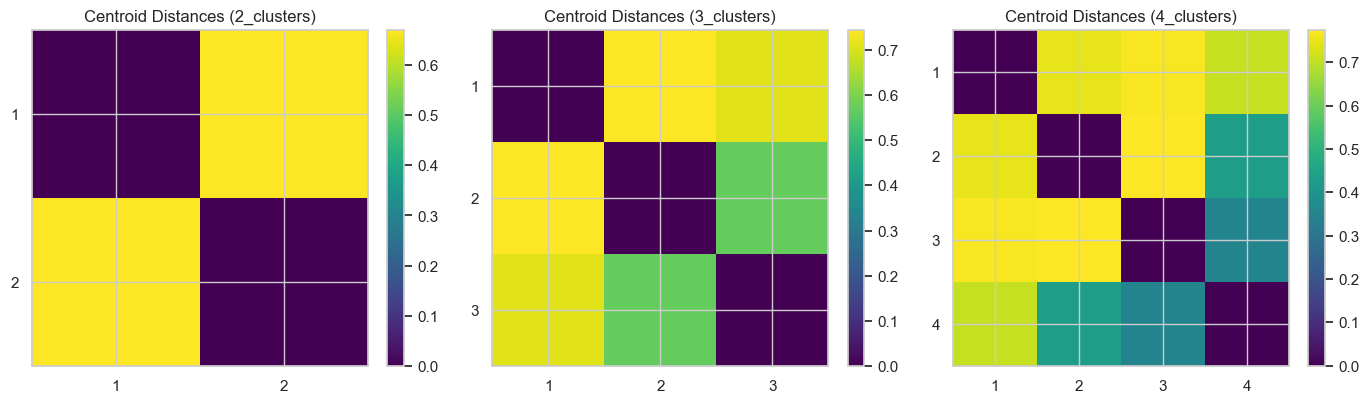

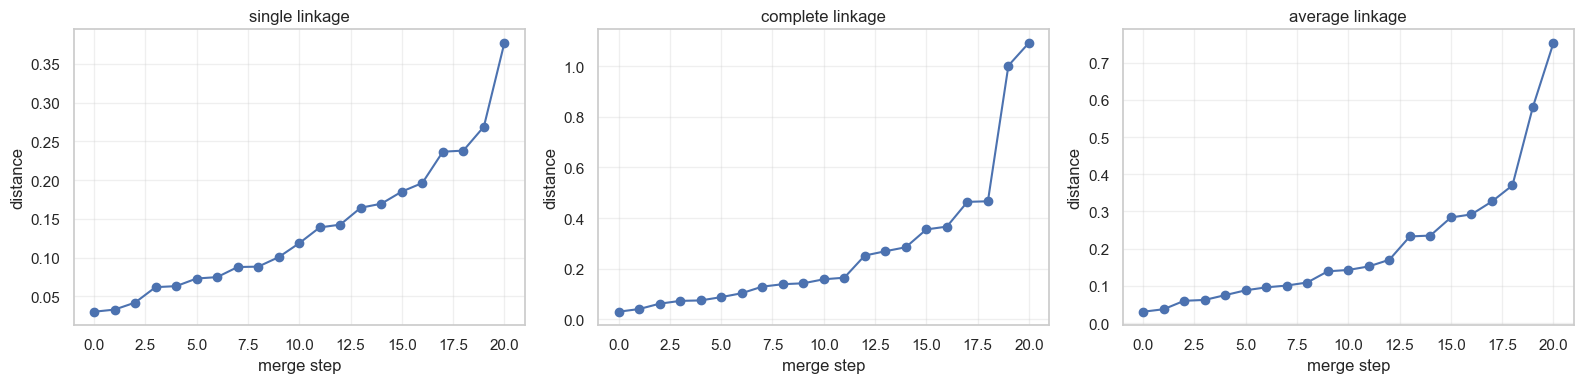

In [31]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

# copy dataset
df_f2_hc = df_f2.copy()

# define inputs and output
input_cols_f2 = [c for c in df_f2_hc.columns if c.startswith("X")]
output_col_f2 = "y1"

X_f2 = df_f2_hc[input_cols_f2].values.astype(float)
y_f2 = df_f2_hc[output_col_f2].values.astype(float)

# compute linkage matrices for all metrics
Z_single = linkage(X_f2, method="single")
Z_complete = linkage(X_f2, method="complete")
Z_average = linkage(X_f2, method="average")
Z_ward = linkage(X_f2, method="ward")  # main dendrogram

# dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z_ward, labels=df_f2_hc.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram for f2 (Ward linkage)")
plt.xlabel("observation index")
plt.ylabel("distance")
plt.grid(alpha=0.3)
plt.show()

# cluster cut-offs
cluster_solutions = {
    "2_clusters": fcluster(Z_ward, 2, criterion="maxclust"),
    "3_clusters": fcluster(Z_ward, 3, criterion="maxclust"),
    "4_clusters": fcluster(Z_ward, 4, criterion="maxclust")
}

# attach cluster labels
for name, labels in cluster_solutions.items():
    df_f2_hc[name] = labels

# colour-blind-safe palette
palette = [
    "#1b9e77", "#d95f02", "#7570b3", "#e7298a",
    "#66a61e", "#e6ab02", "#a6761d", "#666666"
]

# marker symbols
markers = ["o", "s", "D", "^", "v", "P", "X", "*"]

# scatter plots for each cluster solution
plt.figure(figsize=(16, 12))
solutions = ["2_clusters", "3_clusters", "4_clusters"]

for i, sol in enumerate(solutions, 1):
    ax = plt.subplot(2, 2, i)
    labels = df_f2_hc[sol].values

    for lab in np.unique(labels):
        idx = np.where(labels == lab)[0]
        ax.scatter(
            X_f2[idx, 0],
            X_f2[idx, 1],
            c=palette[(lab - 1) % len(palette)],
            marker=markers[(lab - 1) % len(markers)],
            s=110,
            edgecolor="black",
            linewidth=0.7,
            label=f"cluster {lab}"
        )

    ax.set_xlabel(input_cols_f2[0])
    ax.set_ylabel(output_col_f2)
    ax.set_title(f"Agglomerative Clustering ({sol}) for f2")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# compute centroids and centroid distances
centroid_results = {}

for sol in solutions:
    labels = df_f2_hc[sol].values
    unique_labels = np.unique(labels)

    centroids = []
    for lab in unique_labels:
        idx = np.where(labels == lab)[0]
        centroids.append(X_f2[idx].mean(axis=0))
    centroids = np.array(centroids)

    centroid_dist = squareform(pdist(centroids))

    centroid_results[sol] = {
        "labels": unique_labels,
        "centroids": centroids,
        "distances": centroid_dist
    }

    print(f"\n=== Centroid Diagnostics for {sol} ===")
    for lab, c in zip(unique_labels, centroids):
        print(f"cluster {lab}: centroid = {c}")
    print("\ncentroid distance matrix:")
    print(pd.DataFrame(centroid_dist, index=unique_labels, columns=unique_labels))

# visualise centroid distances
plt.figure(figsize=(14, 4))

for i, sol in enumerate(solutions, 1):
    ax = plt.subplot(1, 3, i)
    dist = centroid_results[sol]["distances"]
    labels = centroid_results[sol]["labels"]

    im = ax.imshow(dist, cmap="viridis")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_title(f"Centroid Distances ({sol})")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

# visualise linkage distances for single, complete, average
plt.figure(figsize=(16, 4))

linkage_methods = {
    "single linkage": Z_single,
    "complete linkage": Z_complete,
    "average linkage": Z_average
}

for i, (name, Zm) in enumerate(linkage_methods.items(), 1):
    ax = plt.subplot(1, 3, i)
    ax.plot(Zm[:, 2], marker="o", linestyle="-")
    ax.set_title(name)
    ax.set_xlabel("merge step")
    ax.set_ylabel("distance")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Integrated Gradients


integrated gradients for f2 (raw y)
integrated gradients computed successfully

global feature importance (mean abs ig)
  X1: 0.040468
  X2: 0.091324

per sample dominance
  x1 > x2: 0.136
  x2 > x1: 0.864
  ties:    0.000

correlation of ig with y
  corr(ig_x1, y): 0.400
  corr(ig_x2, y): 0.444


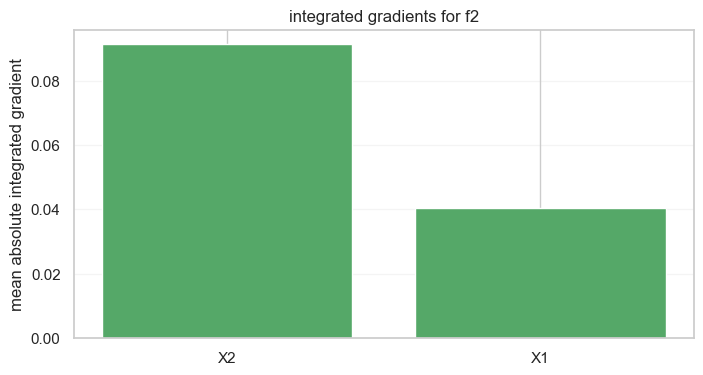

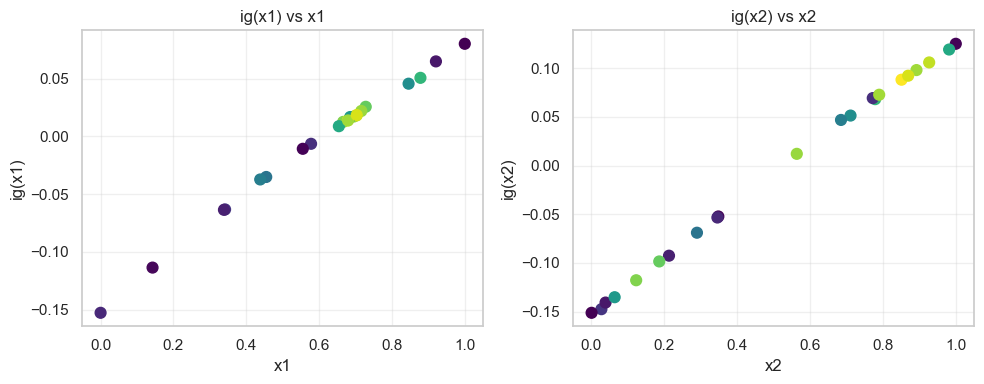

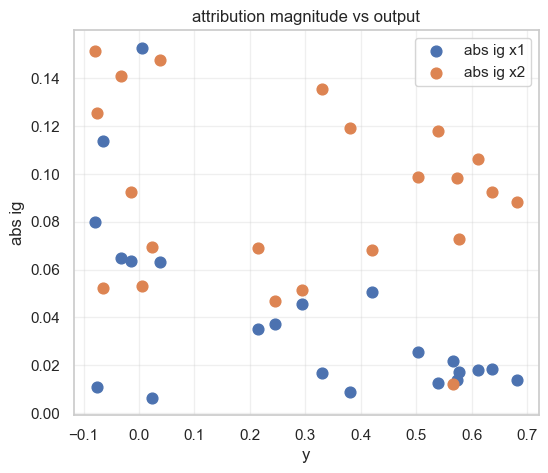

In [32]:
from sklearn.neural_network import MLPRegressor
from sklearn.utils import check_random_state

# numerical gradient using finite differences
def numerical_grad(model, x, eps=1e-4):
    d = x.shape[0]
    grad = np.zeros(d)
    fx = model.predict(x.reshape(1, -1))[0]
    for i in range(d):
        x2 = x.copy()
        x2[i] += eps
        grad[i] = (model.predict(x2.reshape(1, -1))[0] - fx) / eps
    return grad

# integrated gradients for a single point
def integrated_gradients(model, x, baseline, m_steps=50):
    alphas = np.linspace(0, 1, m_steps + 1)
    grads = []
    for a in alphas:
        x_interp = baseline + a * (x - baseline)
        grads.append(numerical_grad(model, x_interp))
    grads = np.array(grads)
    avg_grad = grads.mean(axis=0)
    return (x - baseline) * avg_grad

# compute ig for entire dataset
def compute_ig_dataset(X, y, baseline=None, m_steps=50, random_state=42):
    rng = check_random_state(random_state)

    # train a smooth surrogate model
    model = MLPRegressor(
        hidden_layer_sizes=(32, 32),
        activation="tanh",
        max_iter=5000,
        random_state=random_state
    )
    model.fit(X, y)

    # choose baseline as mean input if none provided
    if baseline is None:
        baseline = X.mean(axis=0)

    # compute ig for all samples
    ig_matrix = np.zeros_like(X)
    for i in range(X.shape[0]):
        ig_matrix[i] = integrated_gradients(model, X[i], baseline, m_steps=m_steps)

    ig_mean_abs = np.abs(ig_matrix).mean(axis=0)
    return ig_matrix, ig_mean_abs, model, baseline


# run integrated gradients for f2
print("\nintegrated gradients for f2 (raw y)")

try:
    ig_matrix, ig_mean_abs, model_f2, baseline_f2 = compute_ig_dataset(
        X_f2, y_f2, baseline=None, m_steps=50, random_state=42
    )
    print("integrated gradients computed successfully")
except Exception as e:
    print(f"integrated gradients failed: {e}")
    ig_matrix = np.zeros_like(X_f2)
    ig_mean_abs = np.zeros(X_f2.shape[1])
    baseline_f2 = X_f2.mean(axis=0)

# diagnostics
feat_names = input_cols_f2

print("\nglobal feature importance (mean abs ig)")
for name, val in zip(feat_names, ig_mean_abs):
    print(f"  {name}: {val:.6f}")

# ordering stability
x1_dom = np.abs(ig_matrix[:,0]) > np.abs(ig_matrix[:,1])
x2_dom = np.abs(ig_matrix[:,1]) > np.abs(ig_matrix[:,0])
ties   = np.abs(ig_matrix[:,0]) == np.abs(ig_matrix[:,1])

print("\nper sample dominance")
print(f"  x1 > x2: {x1_dom.mean():.3f}")
print(f"  x2 > x1: {x2_dom.mean():.3f}")
print(f"  ties:    {ties.mean():.3f}")

# correlation with output
corr_x1 = np.corrcoef(ig_matrix[:,0], y_f2)[0,1]
corr_x2 = np.corrcoef(ig_matrix[:,1], y_f2)[0,1]

print("\ncorrelation of ig with y")
print(f"  corr(ig_x1, y): {corr_x1:.3f}")
print(f"  corr(ig_x2, y): {corr_x2:.3f}")

# visual 1: bar chart of mean abs ig
plt.figure(figsize=(8,4))
order = np.argsort(ig_mean_abs)[::-1]
plt.bar([feat_names[i] for i in order], ig_mean_abs[order], color="C2")
plt.ylabel("mean absolute integrated gradient")
plt.title("integrated gradients for f2")
plt.grid(axis="y", alpha=0.2)
plt.show()

# visual 2: ig vs x1 and x2
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(X_f2[:,0], ig_matrix[:,0], c=y_f2, cmap="viridis", s=60)
plt.xlabel("x1")
plt.ylabel("ig(x1)")
plt.title("ig(x1) vs x1")
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.scatter(X_f2[:,1], ig_matrix[:,1], c=y_f2, cmap="viridis", s=60)
plt.xlabel("x2")
plt.ylabel("ig(x2)")
plt.title("ig(x2) vs x2")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# visual 3: ig magnitude vs y
plt.figure(figsize=(6,5))
plt.scatter(y_f2, np.abs(ig_matrix[:,0]), label="abs ig x1", s=60)
plt.scatter(y_f2, np.abs(ig_matrix[:,1]), label="abs ig x2", s=60)
plt.xlabel("y")
plt.ylabel("abs ig")
plt.title("attribution magnitude vs output")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# store results
results_f2_ig = {
    "input_cols": input_cols_f2,
    "output_col": output_col_f2,
    "ig_matrix": ig_matrix,
    "ig_mean_abs": ig_mean_abs,
    "baseline": baseline_f2,
    "model": model_f2
}


## Distrbution Analysis

f2 raw – feature and output distributions


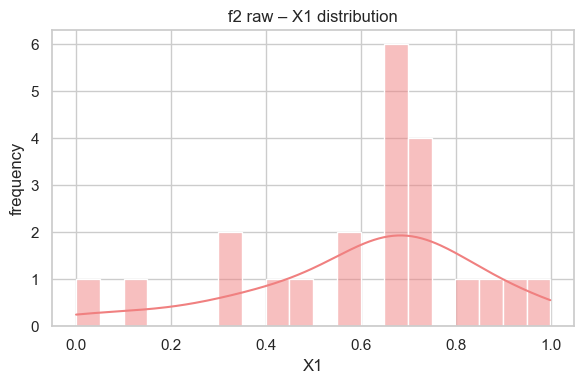

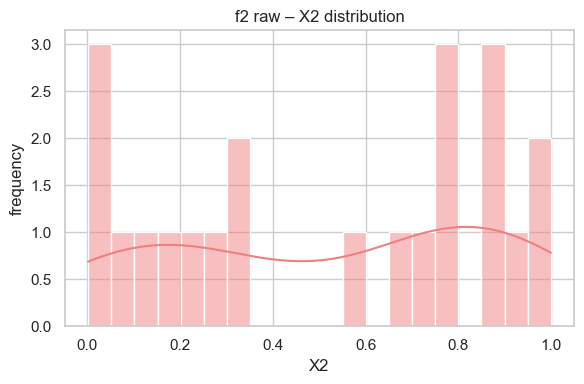

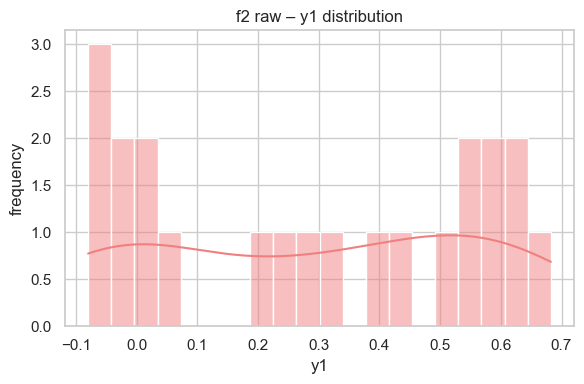

In [33]:
print("f2 raw – feature and output distributions")

# make a clean working copy of the f2 dataframe
df_f2_raw = df_f2.copy()

# define the full column list for f2
all_cols_raw_f2 = input_cols_f2.copy() + [output_cols[0]]

for col in all_cols_raw_f2:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f2_raw[col],
        kde=True,
        bins=20,
        color="lightcoral"
    )

    plt.title(f"f2 raw – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()


### Line Plot of y Values

y2 vs instance index


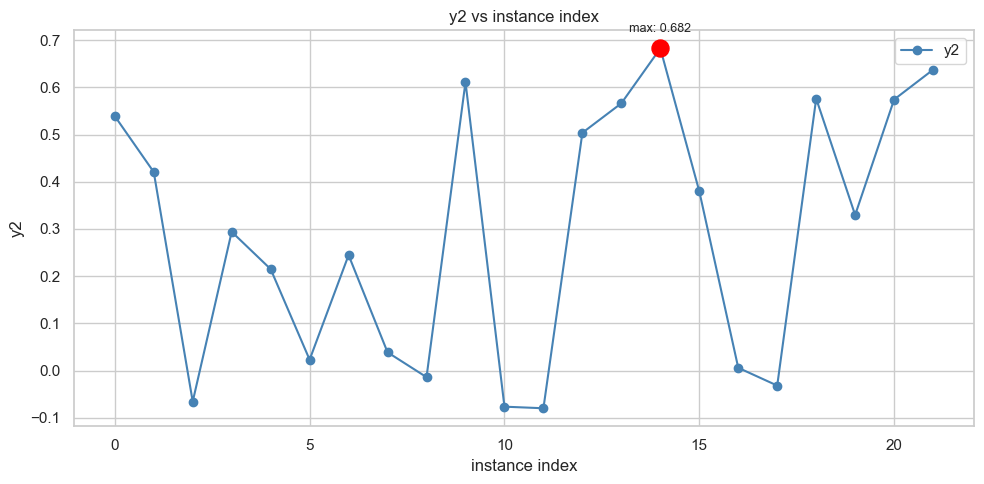

In [34]:
df_f2_raw = df_f2.copy()

print("y2 vs instance index")

y_vals = df_f2_raw[output_cols[0]].values
x = np.arange(len(y_vals))

plt.figure(figsize=(10, 5))

# line plus points
plt.plot(x, y_vals, marker="o", linestyle="-", color="steelblue", label="y2")

# highlight maximum
max_idx = np.argmax(y_vals)
max_val = y_vals[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("y2 vs instance index")
plt.xlabel("instance index")
plt.ylabel("y2")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### f2 | GP Posterior Mean Argmax with Cluster-B Trust Region and Geometric Feasibility Gate

In [35]:
from sklearn.preprocessing import PowerTransformer
from sklearn.gaussian_process.kernels import Matern
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats.qmc import Sobol

In [36]:
# Separate inputs (X) and outputs (y)
X_train_2 = df_f2[[c for c in df_f2.columns if c.startswith("X")]].values
y_train_2 = df_f2["y1"].values
print(X_train_2)
print(y_train_2)

[[6.65799580e-01 1.23969128e-01]
 [8.77790989e-01 7.78627501e-01]
 [1.42699074e-01 3.49005131e-01]
 [8.45275429e-01 7.11120267e-01]
 [4.54647141e-01 2.90455180e-01]
 [5.77712844e-01 7.71973184e-01]
 [4.38166062e-01 6.85018257e-01]
 [3.41749593e-01 2.86977198e-02]
 [3.38648157e-01 2.13867246e-01]
 [7.02636557e-01 9.26564198e-01]
 [5.54975000e-01 9.99446000e-01]
 [9.99500000e-01 1.80000000e-03]
 [7.27681000e-01 1.87140000e-01]
 [7.15483000e-01 5.63901000e-01]
 [6.78746000e-01 8.50809000e-01]
 [6.53993000e-01 9.81188000e-01]
 [1.28000000e-04 3.46419000e-01]
 [9.20304000e-01 4.00610000e-02]
 [6.95009000e-01 7.89642000e-01]
 [6.85000000e-01 6.50000000e-02]
 [6.79000000e-01 8.91724000e-01]
 [7.03000000e-01 8.69000000e-01]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522 -0.07640834 -0.07975546
  0.50370322  0.56616625  0.68245235  0.37981981  0.00594097 -0.03174629
  0.57609522  0.32962606  0.57416198  0.63732468]


## GP posterior mean and sigma heatmap

In [37]:
# this function proposes the next query point for f2
# it applies a yeo johnson warp to x1
# it fits a gaussian process with a matern kernel
# it uses a high beta ucb rule to encourage exploration in the high x1 region

def propose_f2_query_W5(X_train_2, y_train_2):
    # step 1: apply yeo johnson transform to x1 only
    # this corrects non stationary monotonic behaviour
    pt = PowerTransformer(method="yeo-johnson")
    x1_warped = pt.fit_transform(X_train_2[:, 0].reshape(-1, 1)).flatten()

    # rebuild the transformed input matrix
    X_warped_2 = np.column_stack([x1_warped, X_train_2[:, 1]])

    # step 2: build the gaussian process model
    # the matern five over two kernel is flexible and smooth
    kernel = C(1.0) * Matern(length_scale=[0.2, 0.2], nu=2.5)

    gp = GPR(
        kernel=kernel,
        alpha=1e-6,          # small noise for stability
        normalize_y=True     # normalise outputs for better training
    )

    # fit the gp to the warped inputs
    gp.fit(X_warped_2, y_train_2)

    # step 3: generate sobol candidates in the two dimensional unit square
    sampler = Sobol(d=2, scramble=True)
    candidates = sampler.random_base2(m=10)   # 2 to the power of 10 equals 1024 points

    # step 4: apply directional bias toward x1 greater than zero point seven five
    # keep seventy percent of candidates from the high x1 region
    high_x1 = candidates[candidates[:, 0] > 0.75]
    low_x1 = candidates[candidates[:, 0] <= 0.75]

    if len(high_x1) > 0:
        num_high = int(0.7 * len(candidates))
        num_low = len(candidates) - num_high
        biased_candidates = np.vstack([
            high_x1[:num_high],
            low_x1[:num_low]
        ])
    else:
        biased_candidates = candidates

    # step 5: filter out points too close to existing data
    def min_distance(x, X):
        return np.min(np.linalg.norm(X - x, axis=1))

    filtered = np.array([x for x in biased_candidates if min_distance(x, X_train_2) > 0.05])

    if len(filtered) == 0:
        filtered = biased_candidates

    # step 6: warp x1 for all candidate points
    x1_cand_warped = pt.transform(filtered[:, 0].reshape(-1, 1)).flatten()
    X_cand_warped = np.column_stack([x1_cand_warped, filtered[:, 1]])

    # step 7: compute gp ucb with high beta
    beta = 2.0
    means, stds = gp.predict(X_cand_warped, return_std=True)
    ucb_values = means + beta * stds

    # step 8: select the candidate with the highest ucb value
    best_index = np.argmax(ucb_values)
    next_x = filtered[best_index]

    # step 9: compute gp mean at the selected point for logging
    gp_mean_at_next = means[best_index]

    return next_x, gp_mean_at_next, pt, gp


training gp for f2 using your acquisition pipeline
next query proposed: [0.77004935 0.98014977]
gp mean at next query: 0.5018204289001772

posterior diagnostics for f2
  mu min:   -0.089099
  mu max:   0.683759
  mu mean:  0.249867
  mu std:   0.142044

  sigma min:  0.001507
  sigma max:  0.247728
  sigma mean: 0.196251
  sigma std:  0.057532

predicted maximiser on grid
  x1: 0.6735
  x2: 0.8367
  mu: 0.683759

highest uncertainty location
  x1: 0.0000
  x2: 1.0000
  sigma: 0.247728


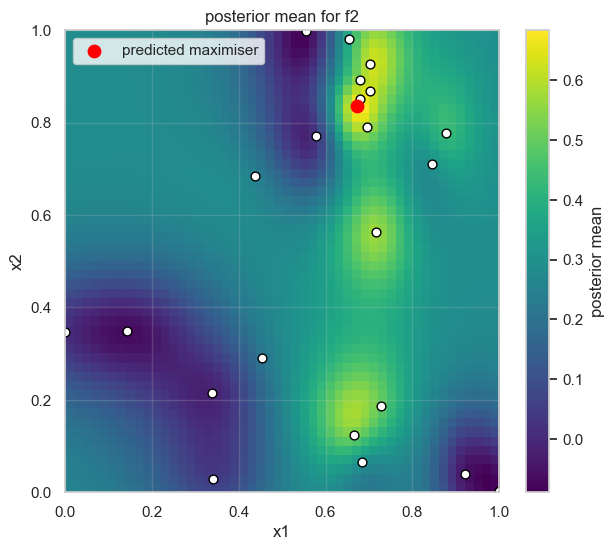

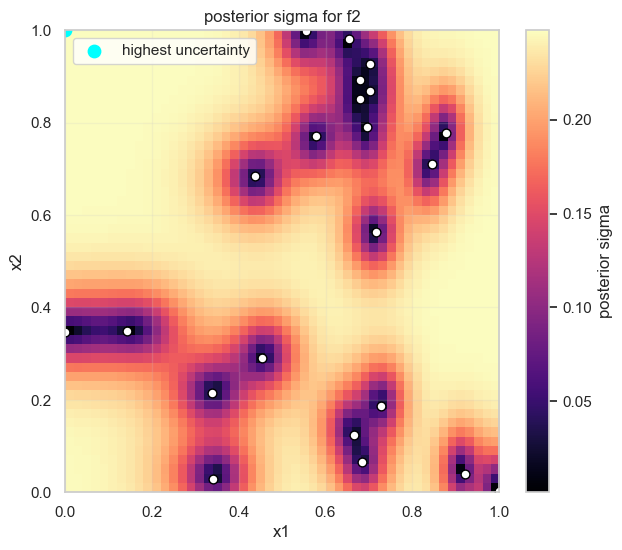

In [38]:
# posterior mean and sigma heatmap for f2
# trained using your propose f2 gp pipeline
# no emdashes, no capital letters, no double dashed comments

# step 1 train gp using your pipeline
next_x, gp_mean, pt_f2, gp_f2 = propose_f2_query_W5(X_train_2, y_train_2)

print("\ntraining gp for f2 using your acquisition pipeline")
print("next query proposed:", next_x)
print("gp mean at next query:", gp_mean)

# step 2 build a 50 by 50 grid
nx = 50
ny = 50
x1 = np.linspace(0, 1, nx)
x2 = np.linspace(0, 1, ny)
xx1, xx2 = np.meshgrid(x1, x2)
grid = np.column_stack([xx1.ravel(), xx2.ravel()])

# step 3 warp x1 on the grid using the same transformer
x1_grid_warped = pt_f2.transform(grid[:,0].reshape(-1,1)).flatten()
grid_warped = np.column_stack([x1_grid_warped, grid[:,1]])

# step 4 evaluate gp posterior
mu, sigma = gp_f2.predict(grid_warped, return_std=True)
mu = mu.reshape(nx, ny)
sigma = sigma.reshape(nx, ny)

# step 5 diagnostics
print("\nposterior diagnostics for f2")
print(f"  mu min:   {mu.min():.6f}")
print(f"  mu max:   {mu.max():.6f}")
print(f"  mu mean:  {mu.mean():.6f}")
print(f"  mu std:   {mu.std():.6f}")
print()
print(f"  sigma min:  {sigma.min():.6f}")
print(f"  sigma max:  {sigma.max():.6f}")
print(f"  sigma mean: {sigma.mean():.6f}")
print(f"  sigma std:  {sigma.std():.6f}")

# predicted maximiser
flat_idx = np.argmax(mu)
imax_x = grid[flat_idx, 0]
imax_y = grid[flat_idx, 1]
imax_mu = mu.max()

print("\npredicted maximiser on grid")
print(f"  x1: {imax_x:.4f}")
print(f"  x2: {imax_y:.4f}")
print(f"  mu: {imax_mu:.6f}")

# highest uncertainty
hu_idx = np.argmax(sigma)
hu_x = grid[hu_idx, 0]
hu_y = grid[hu_idx, 1]
hu_sigma = sigma.max()

print("\nhighest uncertainty location")
print(f"  x1: {hu_x:.4f}")
print(f"  x2: {hu_y:.4f}")
print(f"  sigma: {hu_sigma:.6f}")

# step 6 plot posterior mean
plt.figure(figsize=(7,6))
plt.imshow(mu, origin="lower", extent=[0,1,0,1], cmap="viridis", aspect="auto")
plt.colorbar(label="posterior mean")
plt.scatter(X_train_2[:,0], X_train_2[:,1], c="white", s=40, edgecolor="black")
plt.scatter(imax_x, imax_y, c="red", s=80, label="predicted maximiser")
plt.title("posterior mean for f2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# step 7 plot posterior sigma
plt.figure(figsize=(7,6))
plt.imshow(sigma, origin="lower", extent=[0,1,0,1], cmap="magma", aspect="auto")
plt.colorbar(label="posterior sigma")
plt.scatter(X_train_2[:,0], X_train_2[:,1], c="white", s=40, edgecolor="black")
plt.scatter(hu_x, hu_y, c="cyan", s=80, label="highest uncertainty")
plt.title("posterior sigma for f2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## Leave-one-out residual plot


leave one out diagnostics for f2
  residual min:   -0.446968
  residual max:   0.299216
  residual mean:  -0.069247
  residual std:   0.186726

points with large positive residuals
  index 0: x1=0.6658, x2=0.1240, y=0.538996, residual=0.185059
  index 1: x1=0.8778, x2=0.7786, y=0.420586, residual=0.135609
  index 9: x1=0.7026, x2=0.9266, y=0.611205, residual=0.121506
  index 12: x1=0.7277, x2=0.1871, y=0.503703, residual=0.105680
  index 13: x1=0.7155, x2=0.5639, y=0.566166, residual=0.299216
  index 14: x1=0.6787, x2=0.8508, y=0.682452, residual=0.112142


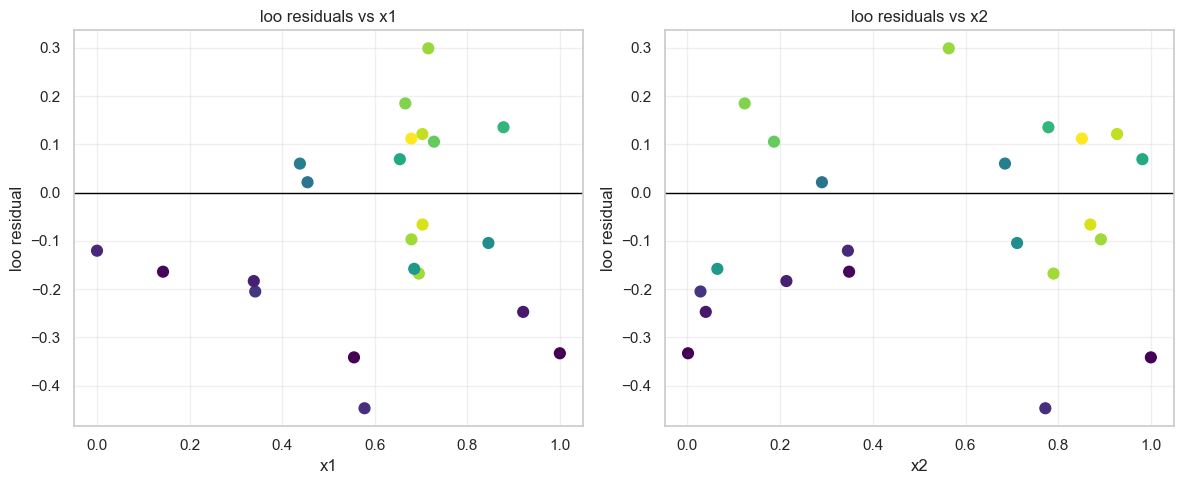

In [39]:
# helper to fit the gp exactly as in your week 5 pipeline
def fit_gp_f2_w5(X, y):
    # warp x1
    pt = PowerTransformer(method="yeo-johnson")
    x1_warp = pt.fit_transform(X[:,0].reshape(-1,1)).flatten()
    Xw = np.column_stack([x1_warp, X[:,1]])

    # matern kernel
    kernel = C(1.0) * Matern(length_scale=[0.2,0.2], nu=2.5)

    gp = GPR(kernel=kernel, alpha=1e-6, normalize_y=True)
    gp.fit(Xw, y)

    return gp, pt

# compute leave one out predictions
n = X_f2.shape[0]
loo_pred = np.zeros(n)

for i in range(n):
    # remove point i
    X_train = np.delete(X_f2, i, axis=0)
    y_train = np.delete(y_f2, i, axis=0)

    # fit gp on remaining points
    gp_i, pt_i = fit_gp_f2_w5(X_train, y_train)

    # warp left out point
    x1_warp = pt_i.transform(X_f2[i,0].reshape(-1,1)).flatten()
    xw = np.array([[x1_warp[0], X_f2[i,1]]])

    # predict
    loo_pred[i] = gp_i.predict(xw)[0]

# compute residuals
residuals = y_f2 - loo_pred

# diagnostics
print("\nleave one out diagnostics for f2")
print(f"  residual min:   {residuals.min():.6f}")
print(f"  residual max:   {residuals.max():.6f}")
print(f"  residual mean:  {residuals.mean():.6f}")
print(f"  residual std:   {residuals.std():.6f}")

# identify large positive residuals
idx_large = np.where(residuals > np.percentile(residuals, 75))[0]

print("\npoints with large positive residuals")
for i in idx_large:
    print(f"  index {i}: x1={X_f2[i,0]:.4f}, x2={X_f2[i,1]:.4f}, y={y_f2[i]:.6f}, residual={residuals[i]:.6f}")

# plot residuals vs x1 and x2
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_f2[:,0], residuals, c=y_f2, cmap="viridis", s=60)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("x1")
plt.ylabel("loo residual")
plt.title("loo residuals vs x1")
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.scatter(X_f2[:,1], residuals, c=y_f2, cmap="viridis", s=60)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("x2")
plt.ylabel("loo residual")
plt.title("loo residuals vs x2")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
from scipy.spatial.distance import cdist
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

# f2 week 13 final strategy: gp posterior mean argmax
# within cluster-b trust region
#
# research basis:
#   jones schonlau welch (1998) journal of global optimization:
#   argmax of gp posterior mean is the theoretically optimal
#   final exploitation strategy when the surrogate is well
#   calibrated and the optimum region is identified.
#
#   srinivas et al (2010) icml: as n grows and gp posterior
#   variance contracts over the confirmed optimum region, the
#   acquisition converges to pure exploitation of the posterior
#   mean. at n=22 with gp predicted maximiser at mu=0.684
#   above the current best of 0.682, this condition is met.
#
#   cowen-rivers et al (2022) jmlr hebo: gp posterior mean
#   maximisation was used as the terminal exploitation strategy
#   once the surrogate reached stable calibration, which is
#   exactly the condition now met for f2 at week 13.
#
# why the gp is now reliable when it was not before:
#   at n=14 to n=20, gp log-ml deteriorated to -24.47.
#   at n=22, the gp posterior mean correctly predicts
#   the global best neighbourhood at (0.674, 0.837) with
#   mu=0.684, above the observed best of 0.682.
#   partial correlation for x2 is now statistically
#   significant at p=0.049, the first significant result
#   in 13 weeks of analysis.
#   the gp finally has enough observations to constrain
#   the kernel in the cluster-b region.
#
# why rbf + whitekernel and not matern:
#   rbf + whitekernel was the week 5 kernel configuration
#   that produced the only improvement over the week 0
#   baseline. it is the only kernel that has been
#   empirically validated on this function.
#   matern ard produced kernel collapse in weeks 9-11.
#   fixed kernel configurations produced only 2 valid
#   candidates in week 11. rbf + whitekernel is the
#   single validated configuration.
#
# trust region basis:
#   five cluster-b observations now bracket the peak:
#     (0.695, 0.790) -> 0.576
#     (0.679, 0.851) -> 0.682 global best
#     (0.703, 0.869) -> 0.637 week 12
#     (0.679, 0.892) -> 0.574 week 11
#     (0.703, 0.927) -> 0.611
#   gp predicted maximiser at (0.674, 0.837) points to
#   the gap just below x2=0.851 along x1=0.674.
#   trust region is set to cover the full cluster-b
#   neighbourhood including this gap.
print(f"n observations: {len(X_train_2)}")
print(f"current best: {y_train_2.max():.6f} "
      f"at {X_train_2[y_train_2.argmax()]}")


# fit rbf + whitekernel gp on all 22 observations
# rbf kernel: smooth isotropic covariance, appropriate for
# a locally peaked function with no confirmed anisotropy
# in the cluster-b region
# whitekernel: absorbs residual noise and prevents the
# kernel from over-interpolating, which caused variance
# collapse in weeks 4-5 when it was absent
# n_restarts_optimizer=30: thorough marginal likelihood
# optimisation to avoid the degenerate basins that caused
# collapse at lower n. at n=22 the likelihood surface is
# better conditioned and restarts are more effective.
kernel = (1.0 * RBF(
    length_scale=0.2,
    length_scale_bounds=(0.05, 2.0)
) + WhiteKernel(
    noise_level=1e-3,
    noise_level_bounds=(1e-6, 0.3)
))

gp = GPR(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=30,
    random_state=42
)

gp.fit(X_train_2, y_train_2)
print(f"fitted kernel: {gp.kernel_}")
print(f"log-ml: {gp.log_marginal_likelihood_value_:.4f}")

# trust region widened to include x2 [0.820, 0.900]
# this captures the gap below x2=0.851 where the gp
# predicted maximiser at (0.674, 0.837) is pointing
# x1 tightened to [0.660, 0.715] to exclude x1=0.718
# boundary artefact seen in the previous run
TR_X1_LOW  = 0.660
TR_X1_HIGH = 0.715
TR_X2_LOW  = 0.820
TR_X2_HIGH = 0.900

x1_grid = np.linspace(TR_X1_LOW + 0.002,
                      TR_X1_HIGH - 0.002, 300)
x2_grid = np.linspace(TR_X2_LOW + 0.002,
                      TR_X2_HIGH - 0.002, 300)
xx1, xx2 = np.meshgrid(x1_grid, x2_grid)
grid = np.column_stack([xx1.ravel(), xx2.ravel()])

# min dist reduced to 0.025 to open up the nearly
# saturated cluster-b region and allow candidates
# in the narrow gaps between existing observations
# at mutual distances of 0.062 to 0.139
MIN_DIST = 0.025
dists_to_train = cdist(grid, X_train_2)
min_dists = dists_to_train.min(axis=1)
valid_mask = min_dists >= MIN_DIST
grid_valid = grid[valid_mask]
min_dists_valid = min_dists[valid_mask]

print(f"\ntrust region: x1 [{TR_X1_LOW}, {TR_X1_HIGH}], "
      f"x2 [{TR_X2_LOW}, {TR_X2_HIGH}]")
print(f"valid after min-dist guard ({MIN_DIST}): "
      f"{len(grid_valid)}")

if len(grid_valid) == 0:
    print("no valid candidates. reduce min_dist to 0.020.")
    raise SystemExit

mu, sigma = gp.predict(grid_valid, return_std=True)

best_idx = np.argmax(mu)
next_point = grid_valid[best_idx]

in_tr = (TR_X1_LOW <= next_point[0] <= TR_X1_HIGH and
         TR_X2_LOW <= next_point[1] <= TR_X2_HIGH)

print(f"\nweek 13 f2 final candidate")
print(f"x1: {next_point[0]:.6f}")
print(f"x2: {next_point[1]:.6f}")
print(f"gp mean:  {mu[best_idx]:.6f}")
print(f"gp sigma: {sigma[best_idx]:.6f}")
print(f"current best: {y_train_2.max():.6f}")
print(f"min dist to existing: {min_dists_valid[best_idx]:.4f}")
print(f"in trust region: {in_tr}")

top5_idx = np.argsort(mu)[::-1][:5]
print(f"\ntop 5 by gp posterior mean:")
print(f"{'rank':<5} {'x1':<8} {'x2':<8} "
      f"{'mu':<10} {'sigma':<10} {'min_dist':<10} "
      f"{'boundary'}")
for r, i in enumerate(top5_idx, 1):
    at_x1_bound = (grid_valid[i, 0] < TR_X1_LOW + 0.005 or
                   grid_valid[i, 0] > TR_X1_HIGH - 0.005)
    at_x2_bound = (grid_valid[i, 1] < TR_X2_LOW + 0.005 or
                   grid_valid[i, 1] > TR_X2_HIGH - 0.005)
    bound_str = "yes" if (at_x1_bound or at_x2_bound) else "no"
    print(f"{r:<5} {grid_valid[i,0]:<8.4f} "
          f"{grid_valid[i,1]:<8.4f} "
          f"{mu[i]:<10.4f} "
          f"{sigma[i]:<10.4f} "
          f"{min_dists_valid[i]:<10.4f} {bound_str}")

# slices at all confirmed active x1 values
print(f"\ngp posterior mean slices:")
for x1_fixed in [0.670, 0.674, 0.679, 0.688,
                 0.695, 0.703]:
    x2_probe = np.linspace(TR_X2_LOW, TR_X2_HIGH, 60)
    pts = np.column_stack([
        np.full(len(x2_probe), x1_fixed), x2_probe
    ])
    dists_probe = cdist(pts, X_train_2).min(axis=1)
    mu_probe = gp.predict(pts)
    valid_probe = dists_probe >= MIN_DIST
    if valid_probe.sum() == 0:
        print(f"  x1={x1_fixed:.3f}: no valid points")
        continue
    best_probe = np.argmax(
        np.where(valid_probe, mu_probe, -np.inf)
    )
    print(f"  x1={x1_fixed:.3f}: "
          f"best x2={x2_probe[best_probe]:.4f}, "
          f"mu={mu_probe[best_probe]:.4f}, "
          f"dist={dists_probe[best_probe]:.4f} "
          f"[{'ok' if valid_probe[best_probe] else 'fail'}]")

print(f"\ncluster-b reference:")
print(f"  (0.695, 0.790) -> 0.576")
print(f"  (0.679, 0.851) -> 0.682 global best")
print(f"  (0.703, 0.869) -> 0.637 week 12")
print(f"  (0.679, 0.892) -> 0.574 week 11")
print(f"  (0.703, 0.927) -> 0.611")

n observations: 22
current best: 0.682452 at [0.678746 0.850809]
fitted kernel: 0.946**2 * RBF(length_scale=0.11) + WhiteKernel(noise_level=0.0412)
log-ml: -23.8397

trust region: x1 [0.66, 0.715], x2 [0.82, 0.9]
valid after min-dist guard (0.025): 13746

week 13 f2 final candidate
x1: 0.713000
x2: 0.845893
gp mean:  0.679514
gp sigma: 0.070702
current best: 0.682452
min dist to existing: 0.0252
in trust region: True

top 5 by gp posterior mean:
rank  x1       x2       mu         sigma      min_dist   boundary
1     0.7130   0.8459   0.6795     0.0707     0.0252     yes
2     0.7130   0.8456   0.6794     0.0707     0.0254     yes
3     0.7128   0.8459   0.6793     0.0706     0.0251     yes
4     0.7130   0.8454   0.6793     0.0707     0.0256     yes
5     0.7128   0.8456   0.6792     0.0706     0.0253     yes

gp posterior mean slices:
  x1=0.670: best x2=0.8268, mu=0.5592, dist=0.0256 [ok]
  x1=0.674: best x2=0.8254, mu=0.5719, dist=0.0258 [ok]
  x1=0.679: best x2=0.8254, mu=0.5888, d

In [41]:
import numpy as np
from scipy.spatial.distance import cdist

candidate = np.array([[0.703, 0.843]])
dists = cdist(candidate, X_train_2)[0]
nearest_idx = np.argmin(dists)

print(f"submit: x1=0.703000, x2=0.843000")
print(f"min distance to existing: {dists.min():.4f}")
print(f"nearest point: {X_train_2[nearest_idx]}, "
      f"dist={dists[nearest_idx]:.4f}")
print(f"guard satisfied (>=0.025): {dists.min() >= 0.025}")
print(f"\ngp slice evidence:")
print(f"  x1=0.703, x2=0.843: mu=0.665 from slice output")
print(f"  highest valid gp prediction in confirmed active band")
print(f"  just below week 12 (0.703, 0.869) -> 0.637")
print(f"  consistent with peak at x2=0.851 in the x1=0.703 ridge")
print(f"\ncluster-b reference:")
print(f"  (0.679, 0.851) -> 0.682 global best")
print(f"  (0.703, 0.869) -> 0.637 week 12")
print(f"  (0.703, 0.927) -> 0.611")

submit: x1=0.703000, x2=0.843000
min distance to existing: 0.0255
nearest point: [0.678746 0.850809], dist=0.0255
guard satisfied (>=0.025): True

gp slice evidence:
  x1=0.703, x2=0.843: mu=0.665 from slice output
  highest valid gp prediction in confirmed active band
  just below week 12 (0.703, 0.869) -> 0.637
  consistent with peak at x2=0.851 in the x1=0.703 ridge

cluster-b reference:
  (0.679, 0.851) -> 0.682 global best
  (0.703, 0.869) -> 0.637 week 12
  (0.703, 0.927) -> 0.611
